# Análisis FBG: 5 Sensores - Fibra Poliamida POLY-1 (19/02/2026)

## 🔬 Contexto del Experimento

**Objetivo**: Caracterización de sensibilidad térmica y de presión de **sensores FBG** en una **nueva fibra de poliamida**.

**Fibra**: POLY-1 con coating de **poliamida** (diferente a las fibras utilizadas en experimentos anteriores).

⚠️ **Características del experimento**:
- Primera adquisición con esta fibra de poliamida
- Los plateaus empiezan aproximadamente a partir de las **16:00h**
- Se analizan **5 sensores FBG de longitudes de onda** (FBG-1, FBG-2, FBG-3, FBG-4, FBG-5)

✅ **NOTA IMPORTANTE**: Esta es una fibra **nueva (POLY-1)** con coating diferente. No se realizan comparaciones con otros experimentos.

Este notebook analiza **sensores FBG** (con 2 polarizaciones cada uno).
Calcula la **media de las polarizaciones** P y S para cada sensor y permite **definir plateaus manualmente**.


## 📋 Configuración:

- **8 RTDs**: 0-3 interiores (1=profundo, 2=medio, 4=superior, 3=superficial), 4-5 vacíos, 6-7 cápsula fibra

- **5 FBGs**: FBG-1, FBG-2, FBG-3, FBG-4, FBG-5 (cada uno con polarización P y S)

- **Análisis**: Media de polarizaciones vs temperatura y presión

- **Plateaus**: Definición manual por presión (empiezan ~16:00h)

- **Acceso a datos**: XRootD remoto vía uproot (no requiere montar /eos/ localmente en lxplus)

## 💡 Notas sobre el flujo de trabajo:

1. **Visualización de plateaus**: La celda justo antes de la sección 6.2 muestra gráficos superpuestos con líneas verticales marcando los plateaus. Para ver estas líneas correctamente, debes **ejecutar primero la sección 6.3** (definición de plateaus) y **luego re-ejecutar la celda de visualización**.

2. **Evolución temporal completa**: La **Sección 7** al final del notebook muestra todo el rango temporal disponible, permitiendo verificar visualmente el TIME_SHIFT de +2 horas aplicado a los datos de wavelength. Puedes filtrar opcionalmente por rango temporal dentro de esa celda.

3. **Datos de presión**: ✅ En esta adquisición los datos de presión funcionan correctamente y se utilizan para definir los plateaus.

## 1️⃣ Importar Librerías

In [15]:
# Reiniciar kernel si hay problemas con imports
import sys
print(f"Python ejecutable: {sys.executable}")
print(f"Python versión: {sys.version}")

# Verificar que scipy está disponible
try:
    import scipy
    print("✅ scipy disponible")
except ImportError:
    print("❌ scipy no encontrado - instalando...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    print("✅ scipy instalado - reinicia el kernel")

Python ejecutable: /usr/bin/python3.11
Python versión: 3.11.13 (main, Jan 16 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-11)]
✅ scipy disponible


In [16]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Cargar Datos del Archivo ROOT

In [17]:
# 🔧 CONFIGURA AQUÍ LA RUTA DE TU ARCHIVO
# Archivo de datos para la fibra de poliamida POLY-1
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260225.root"

# ⚙️ CONFIGURAR TIME_SHIFT (corrección temporal para wavelength)
# Los picos tienen un desfase de +2h respecto a temperatura
TIME_SHIFT = datetime.timedelta(hours=2)  # ✅ Shift confirmado para este dataset

print(f"📂 Cargando archivo ROOT para fibra POLY-1: {filepath}")
print(f"⏱️  TIME_SHIFT configurado: {TIME_SHIFT.total_seconds()/3600:.1f} horas")

# Verificar que el archivo existe
import os
if not os.path.exists(filepath):
    print(f"❌ ERROR: Archivo no encontrado: {filepath}")
    raise FileNotFoundError(f"El archivo {filepath} no existe")

# Verificar tamaño del archivo
file_size = os.path.getsize(filepath)
print(f"📊 Tamaño del archivo: {file_size / (1024**2):.2f} MB")

if file_size < 1000:  # Menos de 1 KB es sospechoso
    print(f"⚠️  ADVERTENCIA: El archivo parece muy pequeño ({file_size} bytes)")
    print(f"   Puede estar corrupto o vacío")

# Cargar datos del archivo ROOT
try:
    print("\n🔄 Abriendo archivo ROOT...")
    file = uproot.open(filepath)
    print("✅ Archivo ROOT abierto correctamente")
    
    # Mostrar estructura del archivo
    print("\n📋 Estructura del archivo ROOT:")
    print(f"   Keys disponibles: {file.keys()}")
    
    # Este archivo tiene estructura diferente: 'peak', 'temp', 'press' en lugar de 'FBG_data'
    print(f"\n🌳 Cargando TTrees individuales...")
    
    # Cargar cada TTree por separado
    tree_peak = file["peak"]
    tree_temp = file["temp"]
    #tree_press = file["press"]
    
    print(f"   ✅ TTree 'peak' cargado: {tree_peak.num_entries} entradas")
    print(f"   ✅ TTree 'temp' cargado: {tree_temp.num_entries} entradas")
    #print(f"   ✅ TTree 'press' cargado: {tree_press.num_entries} entradas")
    
    print(f"\n   Branches en 'peak': {tree_peak.keys()}")
    print(f"   Branches en 'temp': {tree_temp.keys()}")
    #print(f"   Branches en 'press': {tree_press.keys()}")
    
    # Extraer datos en arrays de NumPy
    print("\n📦 Extrayendo datos a arrays NumPy...")
    data_peak = tree_peak.arrays(library="np")
    data_temp = tree_temp.arrays(library="np")
    #data_press = tree_press.arrays(library="np")
    
    # Combinar en un solo diccionario para compatibilidad con el resto del código
    data = {}
    
    # Agregar datos de wavelength (picos)
    for key in data_peak.keys():
        data[key] = data_peak[key]
    
    # Agregar datos de temperatura
    for key in data_temp.keys():
        data[key] = data_temp[key]

    
    print(f"\n✅ Datos extraídos y combinados correctamente")
    print(f"   Total de branches: {len(data.keys())}")
    print(f"   Keys disponibles: {list(data.keys())}")

except FileNotFoundError:
    print(f"\n❌ ERROR CRÍTICO: No se puede acceder al archivo")
    print(f"   Ruta: {filepath}")
    print(f"   Verifica que:")
    print(f"   1. Estás ejecutando desde lxplus")
    print(f"   2. El archivo existe en /eos/")
    print(f"   3. Tienes permisos de lectura")
    raise
except Exception as e:
    print(f"\n❌ ERROR al cargar datos: {e}")
    print(f"   Tipo de error: {type(e).__name__}")
    import traceback
    traceback.print_exc()
    raise

# Verificar que tenemos los datos esperados
print(f"\n🔍 Verificando datos cargados...")
print(f"   Keys totales: {len(data.keys())}")

# Extraer timestamps
try:
    # En este archivo: peak tiene timestamps 2D (medidas, polarizaciones)
    # Usar la primera polarización para los timestamps
    time_wavelength_raw = data_peak["t"][:, 0]  # Timestamps wavelength (primera polarización)
    time_temp_raw = data_temp["t"]  # Timestamps de temperatura (1D)
    #time_press_raw = data_press["t"]  # Timestamps de presión (1D)
    
    print(f"\n⏰ Timestamps extraídos:")
    print(f"   Wavelength: {len(time_wavelength_raw)} puntos")
    print(f"   Temperature: {len(time_temp_raw)} puntos")
    #print(f"   Pressure: {len(time_press_raw)} puntos")
    
    time_wavelength = np.array([datetime.datetime.fromtimestamp(float(t)) for t in time_wavelength_raw])
    time_temp = np.array([datetime.datetime.fromtimestamp(float(t)) for t in time_temp_raw])
    #time_press = np.array([datetime.datetime.fromtimestamp(float(t)) for t in time_press_raw])
    
    print(f"\n📅 Rango temporal (wavelength):")
    print(f"   Inicio: {time_wavelength[0]}")
    print(f"   Fin: {time_wavelength[-1]}")
    print(f"   Duración: {time_wavelength[-1] - time_wavelength[0]}")
    
    print(f"\n📅 Rango temporal (temperatura):")
    print(f"   Inicio: {time_temp[0]}")
    print(f"   Fin: {time_temp[-1]}")
    print(f"   Duración: {time_temp[-1] - time_temp[0]}")

    
    # APLICAR TIME_SHIFT SOLO A WAVELENGTH
    time_wavelength_shifted = time_wavelength + TIME_SHIFT
    print(f"\n✅ TIME_SHIFT aplicado a wavelength (+{TIME_SHIFT.total_seconds()/3600:.1f}h)")
    print(f"   Nuevo inicio wavelength: {time_wavelength_shifted[0]}")
    print(f"   Nuevo fin wavelength: {time_wavelength_shifted[-1]}")
    
except KeyError as e:
    print(f"\n❌ ERROR: No se encontró la rama de tiempo esperada: {e}")
    print(f"   Ramas disponibles: {list(data.keys())}")
    raise
except Exception as e:
    print(f"\n❌ ERROR al procesar timestamps: {e}")
    raise

print(f"\n" + "="*60)
print("🎉 DATOS CARGADOS EXITOSAMENTE - Fibra POLY-1")
print("="*60)

📂 Cargando archivo ROOT para fibra POLY-1: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260225.root
⏱️  TIME_SHIFT configurado: 2.0 horas
📊 Tamaño del archivo: 71.89 MB

🔄 Abriendo archivo ROOT...
✅ Archivo ROOT abierto correctamente

📋 Estructura del archivo ROOT:
   Keys disponibles: ['peak;5', 'temp;3']

🌳 Cargando TTrees individuales...
   ✅ TTree 'peak' cargado: 866000 entradas
   ✅ TTree 'temp' cargado: 3441 entradas

   Branches en 'peak': ['t', 'wav', 'sweep', 'ch', 'pos']
   Branches en 'temp': ['t', 'temp']

📦 Extrayendo datos a arrays NumPy...

✅ Datos extraídos y combinados correctamente
   Total de branches: 6
   Keys disponibles: ['t', 'wav', 'sweep', 'ch', 'pos', 'temp']

🔍 Verificando datos cargados...
   Keys totales: 6

⏰ Timestamps extraídos:
   Wavelength: 866000 puntos
   Temperature: 3441 puntos

📅 Rango temporal (wavelength):
   Inicio: 2026-02-25 08:56:23.839940
   Fin: 2026-02-25 11:47:16.664507
   Duración: 2:50:52.824567

📅 Rango temporal (temperat

### 📊 Visualización de Presión y Temperatura

✅ **En esta adquisición los datos de presión funcionan correctamente**. Este plot muestra la evolución de presión y temperatura durante el experimento.

## 3️⃣ Filtrar Rango Temporal

In [18]:
# 📊 Número de sensores FBG a analizar
num_sensores = 5  # Este experimento tiene 5 sensores FBG

# Extraer wavelengths y calcular media de polarizaciones
# Estructura de wav: (n_medidas, 2_polarizaciones, 5_sensores)
wav_raw = data_peak["wav"]

# wav_raw ya tiene forma (n_medidas, 2, num_sensores)
# Necesitamos reordenarlo a (n_medidas, num_sensores, 2) para media
wav_reshaped = np.transpose(wav_raw, (0, 2, 1))  # (n_medidas, num_sensores, 2_pol)

# Calcular media entre polarizaciones para cada sensor
wav_mean = np.mean(wav_reshaped, axis=2)  # (n_medidas, num_sensores)

# Extraer arrays de temperatura (8 RTDs)
temp_raw = data_temp["temp"]

# Crear array de tiempos wavelength (ya con shift aplicado) para compatibilidad
times_all = time_wavelength_shifted

# Crear array de tiempos temperatura (sin shift)
times_temp = time_temp

# Crear array de tiempos presión (sin shift)
#times_press = time_press

# Datos de presión
#press_raw = data_press["press"]

# press_raw tiene forma (n_medidas, 1) - extraer primera columna
#if len(press_raw.shape) > 1:
    #press_data_plot = press_raw[:, 0]
#else:
    #press_data_plot = press_raw
    
#print(f"✅ Datos de presión cargados: {len(press_data_plot):,} puntos")

print(f"\n📊 Resumen de datos cargados:")
print(f"   Wavelength (media pol): {wav_mean.shape} = {wav_mean.shape[0]:,} medidas × {num_sensores} sensores")
print(f"   Temperatura: {temp_raw.shape} = {temp_raw.shape[0]:,} medidas × 8 RTDs")
#print(f"   Presión: {len(press_data_plot):,} medidas")
print(f"   Timestamps wavelength: {len(times_all):,}")
print(f"   Timestamps temperatura: {len(times_temp):,}")
#print(f"   Timestamps presión: {len(times_press):,}")

# ============================================================================
# ⬅️ AJUSTA AQUÍ EL RANGO TEMPORAL QUE QUIERES ANALIZAR
# ============================================================================
use_full_range = False  # Cambiar a False para rango específico

if use_full_range:
    t_inicio = times_all[0]
    t_fin = times_all[-1]
else:
    fecha = datetime.date(2026, 2, 25)
    t_inicio = datetime.datetime.combine(fecha, datetime.time(12, 10))
    t_fin = datetime.datetime.combine(fecha, datetime.time(13, 45))

# Filtrar wavelength (tiene TIME_SHIFT aplicado)
mask_time = (times_all >= t_inicio) & (times_all <= t_fin)
times_filtered = times_all[mask_time]
wav_filtered = wav_raw[mask_time]

# Filtrar temperatura
mask_time_temp = (times_temp >= t_inicio) & (times_temp <= t_fin)
temp_filtered = temp_raw[mask_time_temp]
times_temp_filtered = times_temp[mask_time_temp]

# Filtrar presión
#mask_time_press = (times_press >= t_inicio) & (times_press <= t_fin)
#press_filtered = press_data_plot[mask_time_press]
#times_press_filtered = times_press[mask_time_press]

print(f"\n✅ Rango seleccionado: {t_inicio.strftime('%Y-%m-%d %H:%M')} - {t_fin.strftime('%H:%M')}")
print(f"   Puntos wavelength: {len(times_filtered):,}")
print(f"   Puntos temperatura: {len(times_temp_filtered):,}")
#print(f"   Puntos presión: {len(times_press_filtered):,}")
if len(times_filtered) == 0:
    print(f"\n⚠️  Sin datos en el rango. Activa 'use_full_range = True' o ajusta t_inicio/t_fin.")


📊 Resumen de datos cargados:
   Wavelength (media pol): (866000, 5) = 866,000 medidas × 5 sensores
   Temperatura: (3441, 8) = 3,441 medidas × 8 RTDs
   Timestamps wavelength: 866,000
   Timestamps temperatura: 3,441

✅ Rango seleccionado: 2026-02-25 12:10 - 13:45
   Puntos wavelength: 319,416
   Puntos temperatura: 1,309


## 4️⃣ Análisis de Temperatura (8 RTDs)

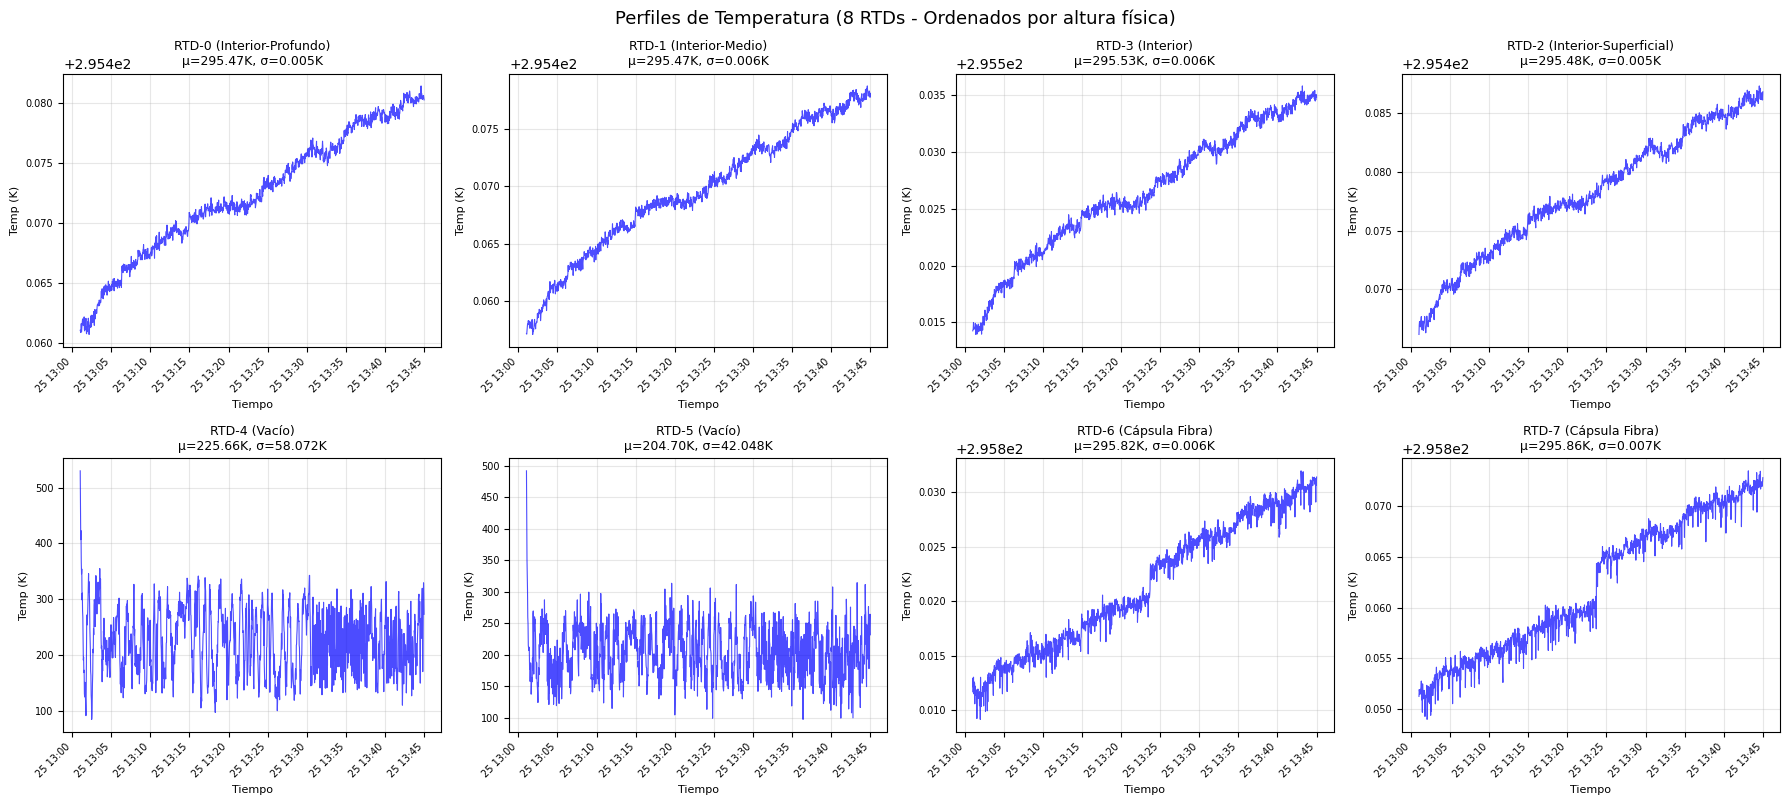


📊 Estadísticas (ordenados por altura física):
RTD-0 (Interior-Profundo)     : μ=295.47K  σ= 0.005K
RTD-1 (Interior-Medio)        : μ=295.47K  σ= 0.006K
RTD-3 (Interior)              : μ=295.53K  σ= 0.006K
RTD-2 (Interior-Superficial)  : μ=295.48K  σ= 0.005K
RTD-4 (Vacío)                 : μ=225.66K  σ=58.072K
RTD-5 (Vacío)                 : μ=204.70K  σ=42.048K
RTD-6 (Cápsula Fibra)         : μ=295.82K  σ= 0.006K
RTD-7 (Cápsula Fibra)         : μ=295.86K  σ= 0.007K


In [19]:
# Configuración RTDs en orden de altura física (de abajo arriba en la vasija)
rtd_sensors_ordered = [
    (0, "RTD-0 (Interior-Profundo)"),      # Más cercano al suelo
    (1, "RTD-1 (Interior-Medio)"),         # Medio
    (3, "RTD-3 (Interior)"),               # Siguiente altura
    (2, "RTD-2 (Interior-Superficial)"),   # Más externo/superficial
    (4, "RTD-4 (Vacío)"),                  # Vacío
    (5, "RTD-5 (Vacío)"),                  # Vacío
    (6, "RTD-6 (Cápsula Fibra)"),          # Dentro de cápsula
    (7, "RTD-7 (Cápsula Fibra)")           # Dentro de cápsula
]

# Plot
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for idx, (sensor_idx, sensor_name) in enumerate(rtd_sensors_ordered):
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    times_valid = times_temp_filtered[mask_valid]
    temp_valid = temp_sensor[mask_valid]
    
    if len(temp_valid) > 0:
        axes[idx].plot(times_valid, temp_valid, 'b-', linewidth=0.8, alpha=0.7)
        axes[idx].set_title(f"{sensor_name}\nμ={np.mean(temp_valid):.2f}K, σ={np.std(temp_valid):.3f}K", fontsize=9)
        axes[idx].set_xlabel('Tiempo', fontsize=8)
        axes[idx].set_ylabel('Temp (K)', fontsize=8)
        axes[idx].grid(True, alpha=0.3)
        axes[idx].tick_params(labelsize=7)
        for label in axes[idx].get_xticklabels():
            label.set_rotation(45)
            label.set_ha('right')

plt.tight_layout()
plt.suptitle('Perfiles de Temperatura (8 RTDs - Ordenados por altura física)', fontsize=13, y=1.00)
plt.show()

print("\n📊 Estadísticas (ordenados por altura física):")
for sensor_idx, sensor_name in rtd_sensors_ordered:
    temp_sensor = temp_filtered[:, sensor_idx]
    mask_valid = temp_sensor > 0
    temp_valid = temp_sensor[mask_valid]
    if len(temp_valid) > 0:
        print(f"{sensor_name:30s}: μ={np.mean(temp_valid):6.2f}K  σ={np.std(temp_valid):6.3f}K")

## 5️⃣ Procesamiento FBG: Filtrado y Media de Polarizaciones

### 5.1 Configuración de 4 Sensores FBG

In [20]:
# ✅ CONFIGURACIÓN: 4 sensores FBG completos
# 4 sensores × 2 polarizaciones = 8 canales
# Índices 0-based: sensor 0, 1, 2, 3 (Python indexing)
fbg_config = [
    {"pol": 0, "sensor": 0, "label": "FBG-1-P"},
    {"pol": 1, "sensor": 0, "label": "FBG-1-S"},
    {"pol": 0, "sensor": 1, "label": "FBG-2-P"},
    {"pol": 1, "sensor": 1, "label": "FBG-2-S"},
    {"pol": 0, "sensor": 2, "label": "FBG-3-P"},
    {"pol": 1, "sensor": 2, "label": "FBG-3-S"},
    {"pol": 0, "sensor": 3, "label": "FBG-4-P"},
    {"pol": 1, "sensor": 3, "label": "FBG-4-S"},
    {"pol": 0, "sensor": 4, "label": "FBG-5-P"},
    {"pol": 1, "sensor": 4, "label": "FBG-5-S"},
]

print(f"✅ Configurados {len(fbg_config)} canales FBG (5 sensores × 2 polarizaciones)")
print(f"💡 Se verificará si FBG-5 tiene datos válidos en este dataset")

✅ Configurados 10 canales FBG (5 sensores × 2 polarizaciones)
💡 Se verificará si FBG-5 tiene datos válidos en este dataset


### 5.2 Filtrado Wavelength (μ±3σ)

In [21]:
def filter_wavelength_data(wav_data, timestamps, sigma_threshold=3.0, use_robust=True):
    """
    Filtra wavelength usando método μ±3σ o método robusto basado en mediana (MAD)
    
    Parameters:
    -----------
    wav_data : array
        Datos de wavelength a filtrar
    timestamps : array
        Timestamps correspondientes
    sigma_threshold : float
        Número de sigmas (o MADs) para el threshold
    use_robust : bool
        Si True, usa MAD (Median Absolute Deviation) en lugar de std
    """
    mask_positive = wav_data > 0
    wav_positive = wav_data[mask_positive]
    
    # Si no hay datos válidos, retornar estructura vacía
    if len(wav_positive) == 0:
        return {
            "timestamps": np.array([]),
            "wavelength": np.array([]),
            "mean": np.nan,
            "std": np.nan,
            "n_valid": 0
        }
    
    if use_robust:
        # Método robusto: usa MEDIANA y MAD (más resistente a outliers)
        median_wav = np.median(wav_positive)
        mad = np.median(np.abs(wav_positive - median_wav))
        # Convertir MAD a escala comparable con std (factor 1.4826)
        sigma_equiv = 1.4826 * mad
        
        threshold_min = median_wav - sigma_threshold * sigma_equiv
        threshold_max = median_wav + sigma_threshold * sigma_equiv
        
        # Filtrar usando los thresholds robustos
        mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
        
        # Calcular estadísticas finales sobre datos filtrados
        wav_filtered = wav_data[mask_filtered]
        mean_wav = np.mean(wav_filtered)
        std_wav = np.std(wav_filtered)
    else:
        # Método clásico: μ±3σ
        mean_wav = np.mean(wav_positive)
        std_wav = np.std(wav_positive)
        threshold_min = mean_wav - sigma_threshold * std_wav
        threshold_max = mean_wav + sigma_threshold * std_wav
        
        mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
    
    return {
        "timestamps": timestamps[mask_filtered],
        "wavelength": wav_data[mask_filtered],
        "mean": mean_wav,
        "std": std_wav,
        "n_valid": np.sum(mask_filtered)
    }

# DIAGNÓSTICO: Verificar forma y valores de los sensores
print(f"🔍 Forma de wav_filtered: {wav_filtered.shape}")
print(f"   Dimensiones: (time={wav_filtered.shape[0]}, pol={wav_filtered.shape[1]}, sensor={wav_filtered.shape[2]})")

# Diagnóstico por sensor (todos los sensores: 0, 1, 2, 3)
print(f"\n🔍 Diagnóstico de valores por sensor (FBG-1, FBG-2, FBG-3, FBG-4, FBG-5):")
for sensor_idx in range(5):  # 0, 1, 2, 3, 4 (incluye FBG-5)
    for pol_idx in range(2):
        pol_name = "P" if pol_idx == 0 else "S"
        sensor_data = wav_filtered[:, pol_idx, sensor_idx]
        n_positive = np.sum(sensor_data > 0)
        if n_positive > 0:
            min_val = np.min(sensor_data[sensor_data > 0])
            max_val = np.max(sensor_data)
            mean_val = np.mean(sensor_data[sensor_data > 0])
        else:
            min_val = max_val = mean_val = 0
        
        print(f"   FBG-{sensor_idx+1}-{pol_name}: {n_positive:7d} pts > 0, range=[{min_val:.2e}, {max_val:.2e}] nm, μ={mean_val:.2e} nm")

# Procesar todos los canales configurados (incluye FBG-5)
# 🔧 CONFIGURACIÓN: Elige el método de filtrado
USE_ROBUST_FILTERING = True  # True = MAD robusto, False = μ±3σ clásico
SIGMA_THRESHOLD = 3.0  # Ajusta este valor si quieres filtrado más o menos estricto (2.5-4.0)

print(f"\n⚙️  Método de filtrado: {'ROBUSTO (MAD)' if USE_ROBUST_FILTERING else 'CLÁSICO (μ±3σ)'}")
print(f"⚙️  Threshold: ±{SIGMA_THRESHOLD}{'×MAD' if USE_ROBUST_FILTERING else 'σ'}")

fbg_filtered_data = {}
for cfg in fbg_config:
    wav_data = wav_filtered[:, cfg["pol"], cfg["sensor"]]  # (time, pol, sensor)
    fbg_filtered_data[cfg["label"]] = filter_wavelength_data(
        wav_data, times_filtered, 
        sigma_threshold=SIGMA_THRESHOLD,
        use_robust=USE_ROBUST_FILTERING
    )

print("\n✅ Filtrado completado (5 sensores procesados)")
print(f"\n{'Sensor':<12} {'Mean (nm)':<12} {'Std (nm)':<12} {'N válidos'}")
print("="*60)
for label, data in fbg_filtered_data.items():
    print(f"{label:<12} {data['mean']:<12.6e} {data['std']:<12.6e} {data['n_valid']}")

🔍 Forma de wav_filtered: (319416, 2, 5)
   Dimensiones: (time=319416, pol=2, sensor=5)

🔍 Diagnóstico de valores por sensor (FBG-1, FBG-2, FBG-3, FBG-4, FBG-5):
   FBG-1-P:  319416 pts > 0, range=[1.54e-06, 1.54e-06] nm, μ=1.54e-06 nm
   FBG-1-S:  319416 pts > 0, range=[1.54e-06, 1.54e-06] nm, μ=1.54e-06 nm
   FBG-2-P:  319416 pts > 0, range=[1.55e-06, 1.55e-06] nm, μ=1.55e-06 nm
   FBG-2-S:  319416 pts > 0, range=[1.55e-06, 1.55e-06] nm, μ=1.55e-06 nm
   FBG-3-P:  319416 pts > 0, range=[1.56e-06, 1.56e-06] nm, μ=1.56e-06 nm
   FBG-3-S:  319416 pts > 0, range=[1.56e-06, 1.56e-06] nm, μ=1.56e-06 nm
   FBG-4-P:  319416 pts > 0, range=[1.56e-06, 1.56e-06] nm, μ=1.56e-06 nm
   FBG-4-S:  319416 pts > 0, range=[1.56e-06, 1.56e-06] nm, μ=1.56e-06 nm
   FBG-5-P:  319416 pts > 0, range=[1.57e-06, 1.57e-06] nm, μ=1.57e-06 nm
   FBG-5-S:  319416 pts > 0, range=[1.57e-06, 1.57e-06] nm, μ=1.57e-06 nm

⚙️  Método de filtrado: ROBUSTO (MAD)
⚙️  Threshold: ±3.0×MAD

✅ Filtrado completado (5 sensores p

### 5.3 Calcular Media de Polarizaciones

In [22]:
# Calcular media P+S para cada sensor (4 sensores: 1, 2, 3, 4, 5)
fbg_mean_data = {}

for sensor_num in [1, 2, 3, 4, 5]:  # Todos los sensores (incluye FBG-5)
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"
    
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    
    times_p = data_p["timestamps"]
    times_s = data_s["timestamps"]
    wav_p = data_p["wavelength"]
    wav_s = data_s["wavelength"]
    
    # Verificar que hay datos válidos
    if len(times_p) == 0 or len(times_s) == 0:
        print(f"⚠️ FBG-{sensor_num} no tiene datos suficientes, omitiendo...")
        continue
    
    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p])
    times_s_sec = np.array([t.timestamp() for t in times_s])
    wav_s_interp = np.interp(times_p_sec, times_s_sec, wav_s)
    
    # Media
    wav_mean = (wav_p + wav_s_interp) / 2.0
    
    fbg_mean_data[label_mean] = {
        "timestamps": times_p,
        "wavelength": wav_mean,
        "mean": np.mean(wav_mean),
        "std": np.std(wav_mean),
        "n_valid": len(wav_mean),
        "sensor_num": sensor_num
    }

print("✅ Medias calculadas (P+S)/2 para todos los sensores")
print(f"\n{'Sensor':<15} {'Mean (nm)':<15} {'Std (nm)':<15} {'N puntos'}")
print("="*65)
for label, data in fbg_mean_data.items():
    print(f"{label:<15} {data['mean']:<15.6e} {data['std']:<15.6e} {data['n_valid']}")

✅ Medias calculadas (P+S)/2 para todos los sensores

Sensor          Mean (nm)       Std (nm)        N puntos
FBG-1-Mean      1.544072e-06    1.844174e-12    319415
FBG-2-Mean      1.550869e-06    1.896441e-12    319412
FBG-3-Mean      1.556367e-06    3.789713e-11    319370
FBG-4-Mean      1.560512e-06    2.365001e-12    319292
FBG-5-Mean      1.566322e-06    2.364997e-12    319118


### 5.4 Visualizar Wavelengths (Media de Polarizaciones)

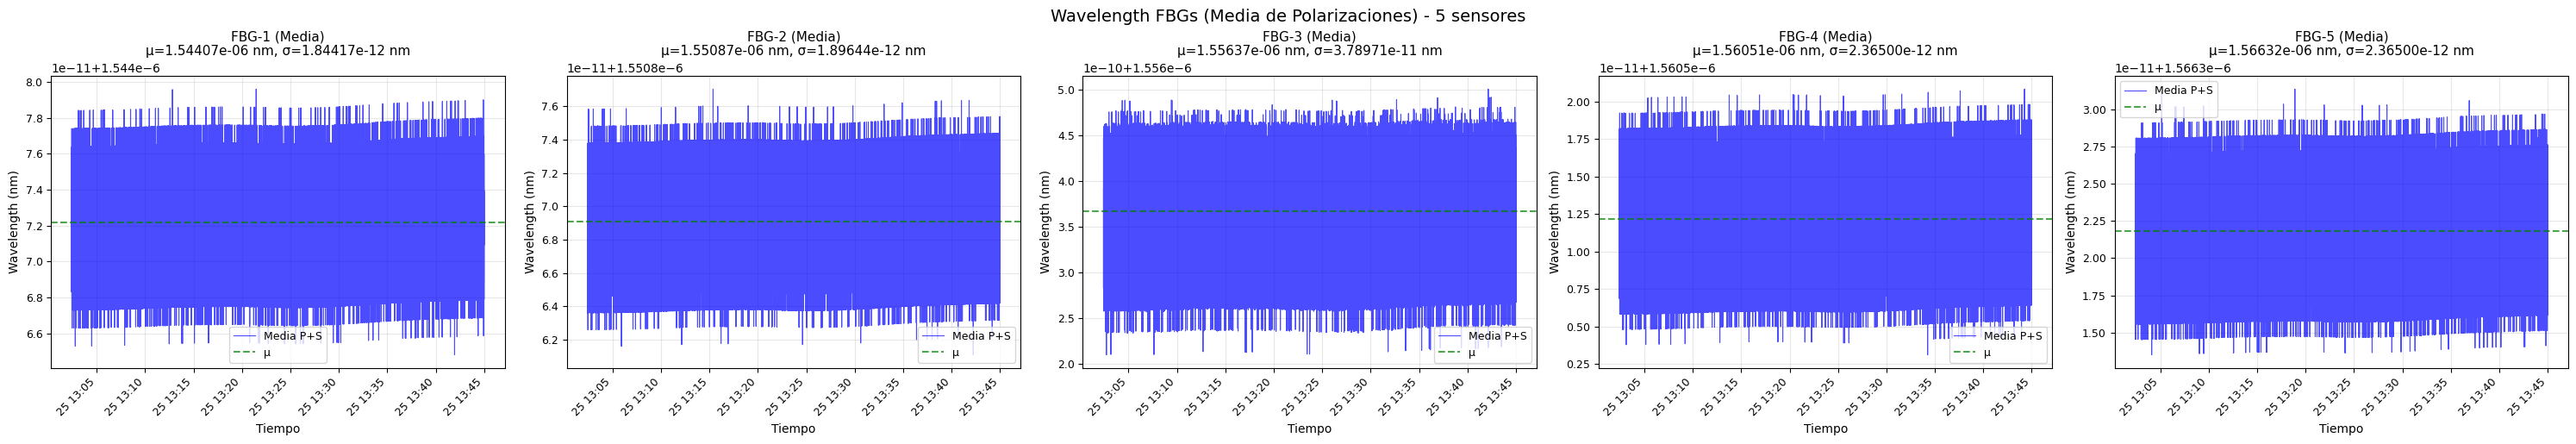

💡 Ejecuta primero la celda 6.3 (definición de plateaus) para ver las líneas verticales


In [23]:
# Ajustar layout para 4 sensores
n_sensors = len(fbg_mean_data)
if n_sensors == 3:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
elif n_sensors == 4:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
else:
    fig, axes = plt.subplots(1, n_sensors, figsize=(6*n_sensors, 5))

if n_sensors == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for idx, (label, data) in enumerate(fbg_mean_data.items()):
    times_fbg = data["timestamps"]
    wav_fbg = data["wavelength"]
    sensor_num = data["sensor_num"]
    
    axes[idx].plot(times_fbg, wav_fbg, 'b-', linewidth=0.8, alpha=0.7, label='Media P+S')
    axes[idx].axhline(data['mean'], color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='μ')
    
    # Añadir líneas verticales de plateaus (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            axes[idx].axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.2, alpha=0.5)
            axes[idx].axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.2, alpha=0.5)
    
    axes[idx].set_title(f"FBG-{sensor_num} (Media)\nμ={data['mean']:.5e} nm, σ={data['std']:.5e} nm", fontsize=11)
    axes[idx].set_xlabel('Tiempo', fontsize=10)
    axes[idx].set_ylabel('Wavelength (nm)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)
    axes[idx].tick_params(labelsize=9)
    
    for tick_label in axes[idx].get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_ha('right')

plt.tight_layout()
plt.suptitle(f'Wavelength FBGs (Media de Polarizaciones) - {n_sensors} sensores', fontsize=14, y=1.02)
plt.show()

if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"💡 Ejecuta primero la celda 6.3 (definición de plateaus) para ver las líneas verticales")

## 6️⃣ Correlación Temperatura/Presión - Wavelength

### 6.1 Seleccionar RTD de Referencia

In [24]:
# Usar RTD-6 (cápsula fibra) como referencia
rtd_ref_idx = 6
rtd_ref_name = "RTD-6 (Cápsula)"

temp_ref = temp_filtered[:, rtd_ref_idx]
mask_temp_valid = temp_ref > 0
times_temp_ref = times_temp_filtered[mask_temp_valid]
temp_ref_valid = temp_ref[mask_temp_valid]

# Presión válida en el rango filtrado
#press_valid_filtered_mask = press_filtered > 0
#times_press_ref = times_press_filtered[press_valid_filtered_mask]
#press_ref_valid = press_filtered[press_valid_filtered_mask]

print(f"✅ Referencia temperatura: {rtd_ref_name}")
print(f"   Rango: [{np.min(temp_ref_valid):.2f}, {np.max(temp_ref_valid):.2f}] K")
#print(f"\n✅ Presión:")
#print(f"   Rango: [{np.min(press_ref_valid):.2f}, {np.max(press_ref_valid):.2f}] bar")

✅ Referencia temperatura: RTD-6 (Cápsula)
   Rango: [295.81, 295.83] K


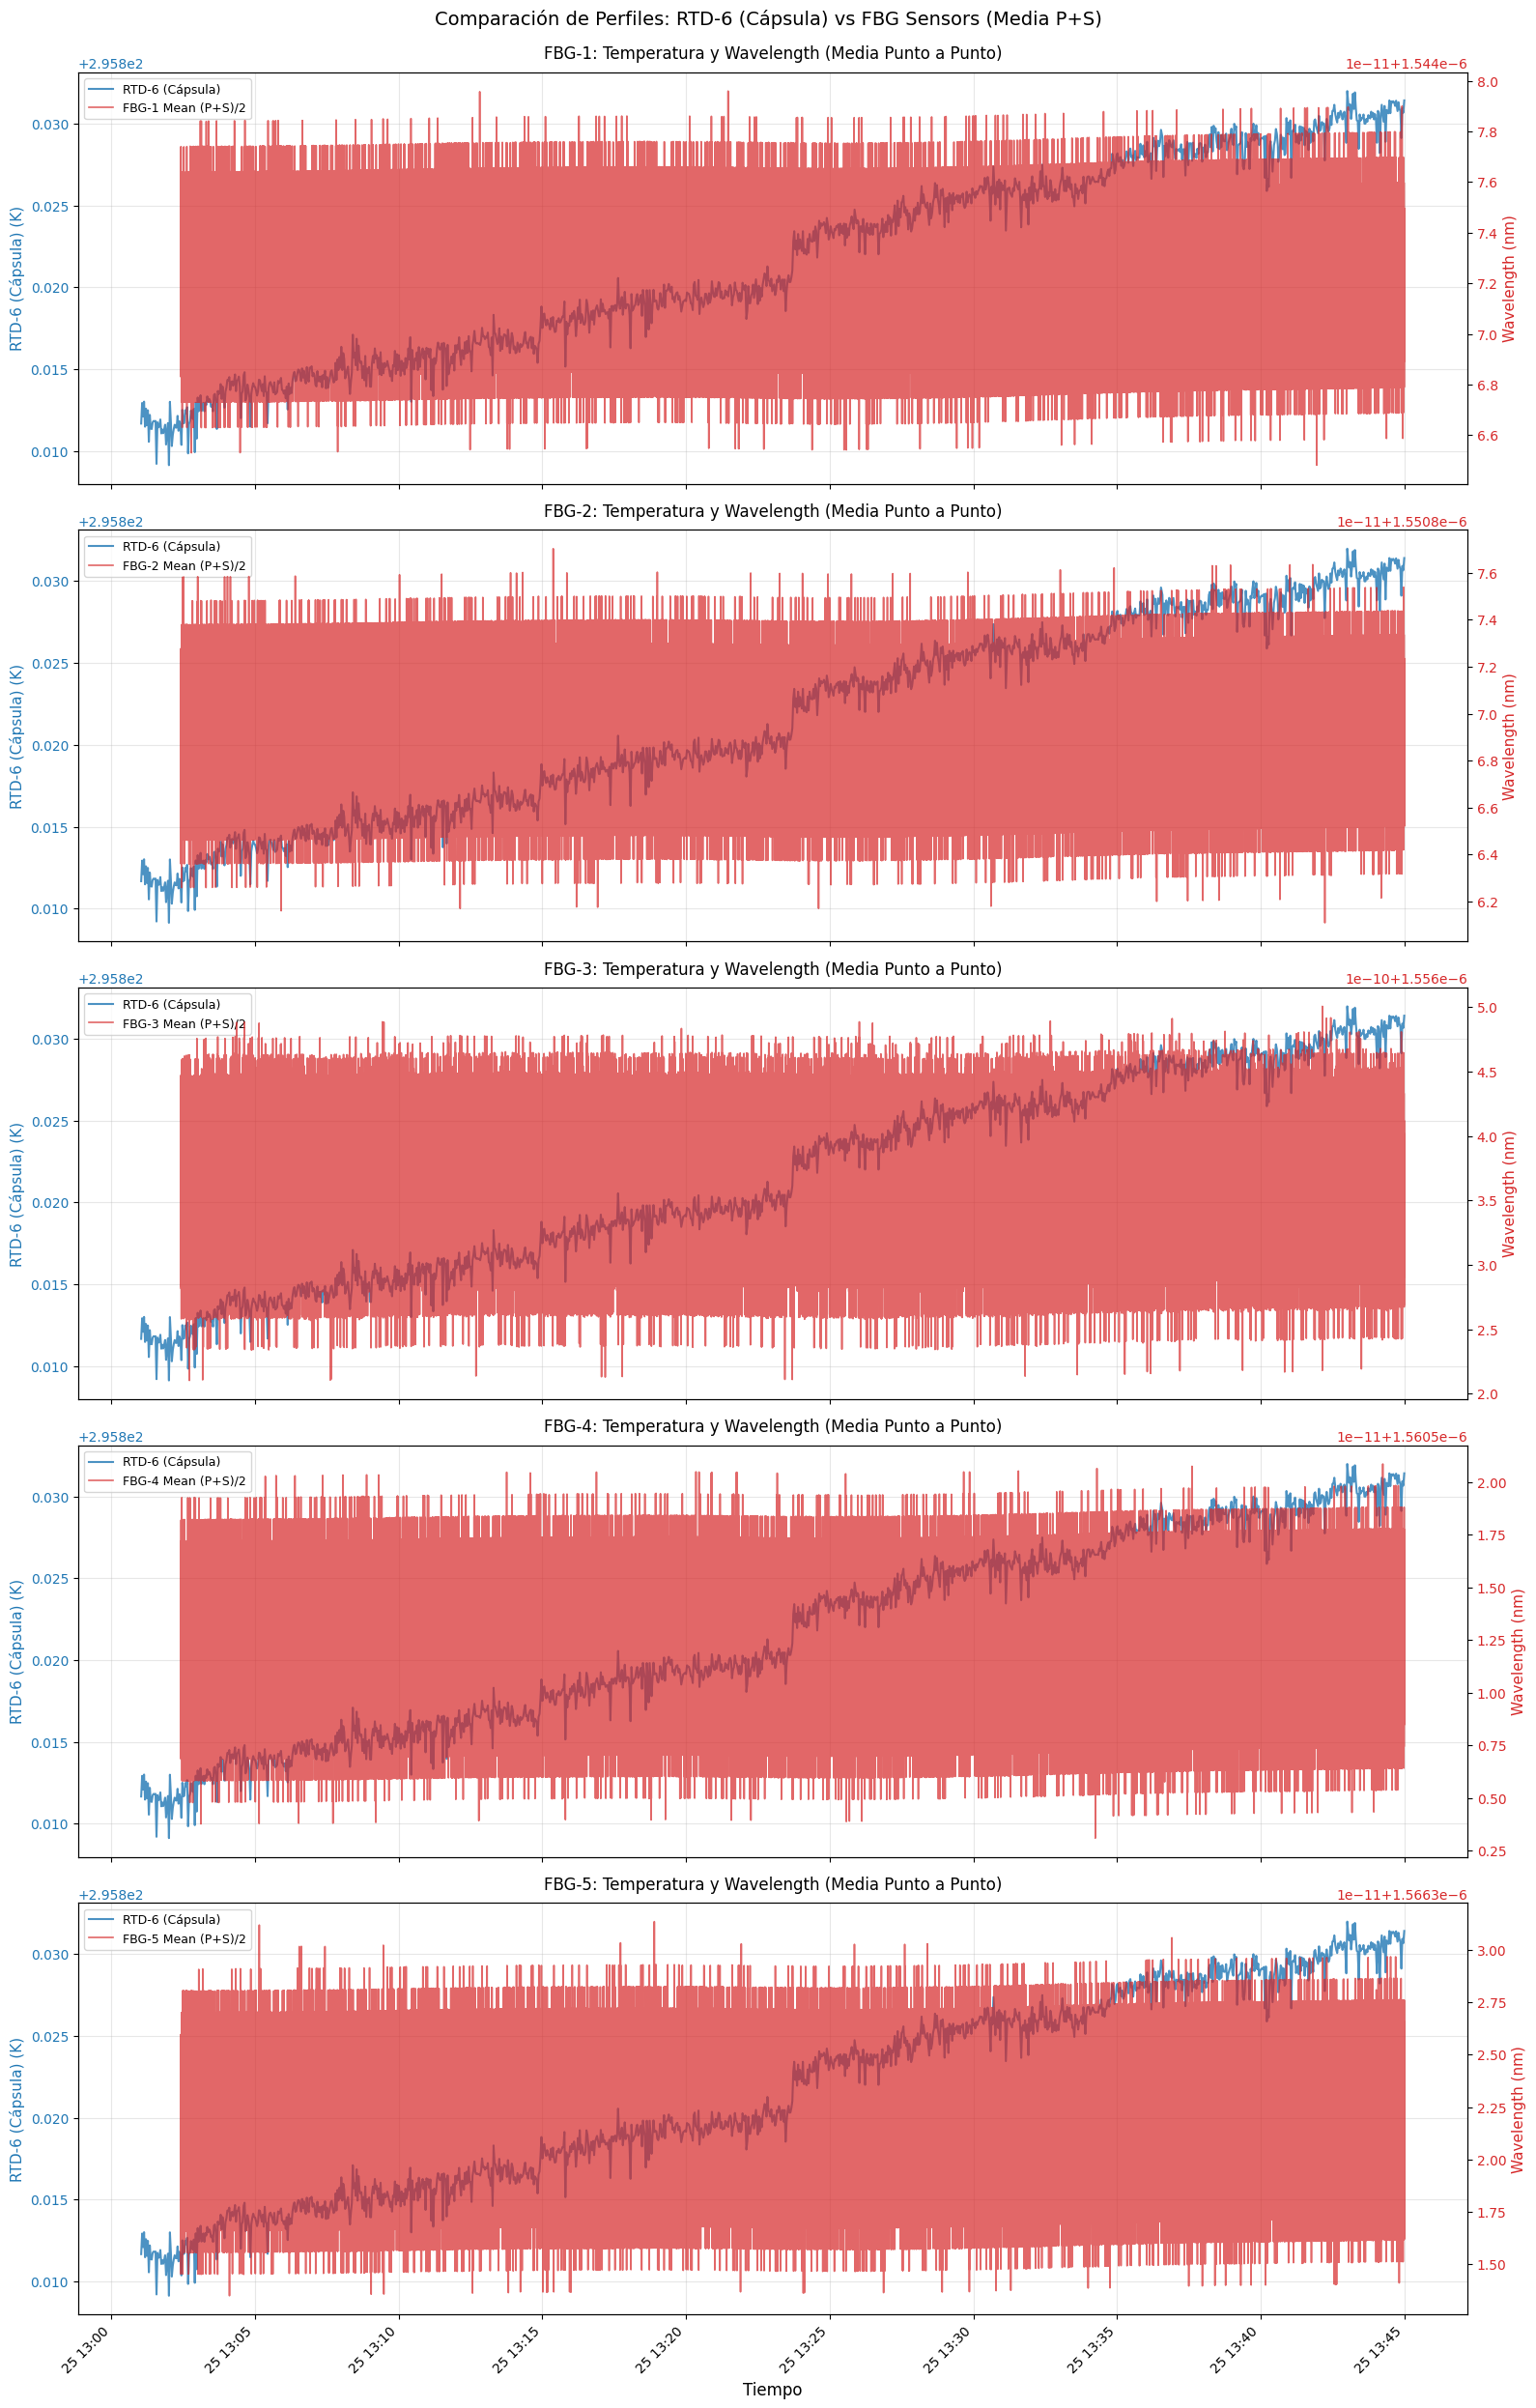

✅ Gráficos superpuestos generados para 5 sensores FBG
   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados


In [25]:
# Superposición de temperatura y wavelength (subplots para cada FBG)

n_sensors_plot = len(fbg_mean_data)

fig, axes = plt.subplots(n_sensors_plot, 1, figsize=(16, 5*n_sensors_plot), sharex=True)


# Asegurar que axes sea un array
if n_sensors_plot == 1:
    axes = [axes]

color_temp = 'tab:blue'
color_wav = 'tab:red'

for idx, sensor_num in enumerate([1, 2, 3, 4, 5][:n_sensors_plot]):
    fbg_label = f"FBG-{sensor_num}-Mean"
    fbg_data_plot = fbg_mean_data[fbg_label]
    
    ax1 = axes[idx]
    
    # Eje izquierdo: Temperatura
    ax1.set_ylabel(f'{rtd_ref_name} (K)', fontsize=11, color=color_temp)
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.8, label=rtd_ref_name)
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.3, axis='both')
    
    # Marcar plateaus con líneas verticales (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            ax1.axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.5, alpha=0.6)
            ax1.axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Eje derecho: Wavelength (media punto a punto P+S)
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=11, color=color_wav)
    ax2.plot(fbg_data_plot["timestamps"], fbg_data_plot["wavelength"], 
             color=color_wav, linewidth=1.2, alpha=0.7, 
             label=f'FBG-{sensor_num} Mean (P+S)/2')
    ax2.tick_params(axis='y', labelcolor=color_wav)
    
    # Leyendas combinadas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    
    # Añadir leyenda para plateaus si existen
    if 'plateau_data' in globals() and len(plateau_data) > 0 and idx == 0:
        from matplotlib.lines import Line2D
        custom_lines = [Line2D([0], [0], color='red', linestyle='--', linewidth=1.5),
                       Line2D([0], [0], color='blue', linestyle='--', linewidth=1.5)]
        ax1.legend(lines1 + lines2 + custom_lines, 
                  labels1 + labels2 + ['Inicio plateau', 'Fin plateau'], 
                  loc='upper left', fontsize=9)
    else:
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    # Título del subplot
    ax1.set_title(f'FBG-{sensor_num}: Temperatura y Wavelength (Media Punto a Punto)', 
                  fontsize=12, pad=10)

# Solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=12)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Comparación de Perfiles: {rtd_ref_name} vs FBG Sensors (Media P+S)', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

print(f"✅ Gráficos superpuestos generados para {n_sensors_plot} sensores FBG")
if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"   🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados")


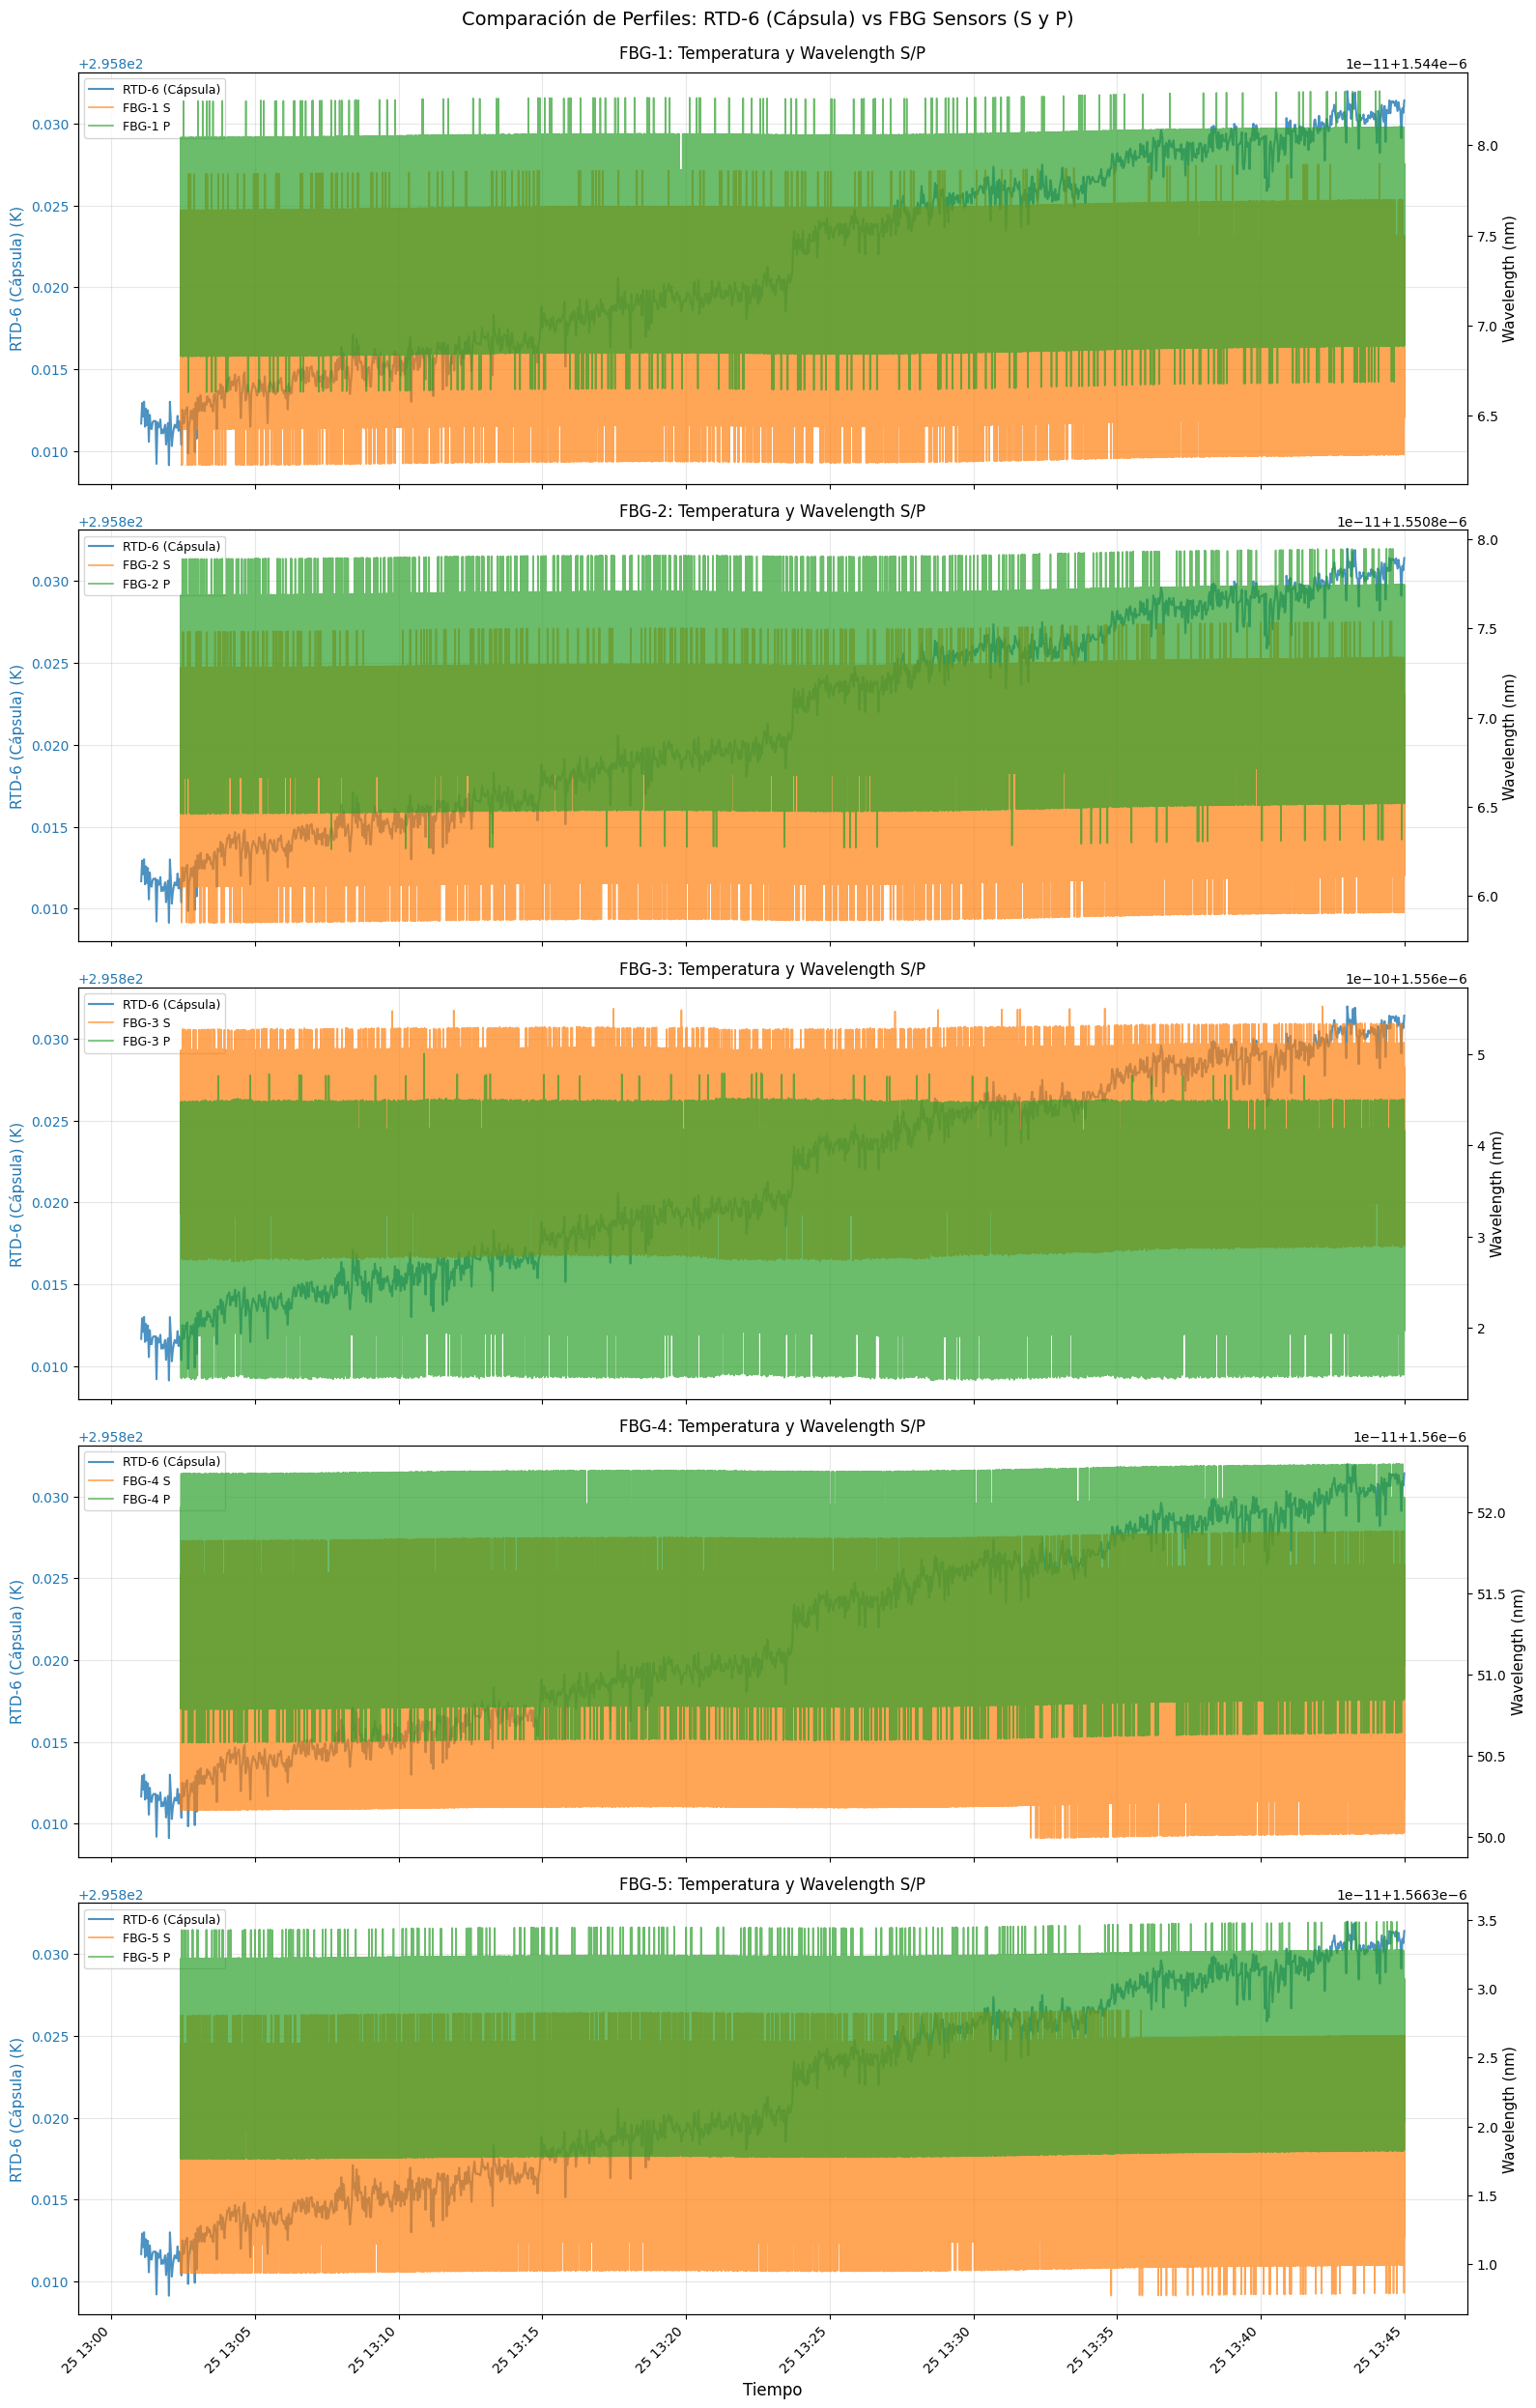

✅ Gráficos superpuestos generados para 5 sensores FBG (S y P)
   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados


In [26]:
# Superposición de temperatura y wavelength para polarizaciones S y P (subplots para cada FBG)

n_sensors_plot = len(fbg_mean_data)

fig, axes = plt.subplots(n_sensors_plot, 1, figsize=(16, 5*n_sensors_plot), sharex=True)


# Asegurar que axes sea un array
if n_sensors_plot == 1:
    axes = [axes]

color_temp = 'tab:blue'
color_wav_s = 'tab:orange'
color_wav_p = 'tab:green'

for idx, sensor_num in enumerate([1, 2, 3, 4, 5][:n_sensors_plot]):
    fbg_label_s = f"FBG-{sensor_num}-S"
    fbg_label_p = f"FBG-{sensor_num}-P"
    data_s = fbg_filtered_data[fbg_label_s]
    data_p = fbg_filtered_data[fbg_label_p]
    
    ax1 = axes[idx]
    
    # Eje izquierdo: Temperatura
    ax1.set_ylabel(f'{rtd_ref_name} (K)', fontsize=11, color=color_temp)
    ax1.plot(times_temp_ref, temp_ref_valid, color=color_temp, linewidth=1.5, alpha=0.8, label=rtd_ref_name)
    ax1.tick_params(axis='y', labelcolor=color_temp)
    ax1.grid(True, alpha=0.3, axis='both')
    
    # Marcar plateaus con líneas verticales (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            ax1.axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.5, alpha=0.6)
            ax1.axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Eje derecho: Wavelength S y P
    ax2 = ax1.twinx()
    ax2.set_ylabel('Wavelength (nm)', fontsize=11)
    ax2.plot(data_s["timestamps"], data_s["wavelength"], 
             color=color_wav_s, linewidth=1.2, alpha=0.7, label=f'FBG-{sensor_num} S')
    ax2.plot(data_p["timestamps"], data_p["wavelength"], 
             color=color_wav_p, linewidth=1.2, alpha=0.7, label=f'FBG-{sensor_num} P')
    ax2.tick_params(axis='y')
    
    # Leyendas combinadas
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    
    # Añadir leyenda para plateaus si existen
    if 'plateau_data' in globals() and len(plateau_data) > 0 and idx == 0:
        from matplotlib.lines import Line2D
        custom_lines = [Line2D([0], [0], color='red', linestyle='--', linewidth=1.5),
                       Line2D([0], [0], color='blue', linestyle='--', linewidth=1.5)]
        ax1.legend(lines1 + lines2 + custom_lines, 
                  labels1 + labels2 + ['Inicio plateau', 'Fin plateau'], 
                  loc='upper left', fontsize=9)
    else:
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)
    
    # Título del subplot
    ax1.set_title(f'FBG-{sensor_num}: Temperatura y Wavelength S/P', 
                  fontsize=12, pad=10)

# Solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=12)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Comparación de Perfiles: {rtd_ref_name} vs FBG Sensors (S y P)', 
             fontsize=14, y=0.995)
plt.tight_layout()
plt.show()

print(f"✅ Gráficos superpuestos generados para {n_sensors_plot} sensores FBG (S y P)")
if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"   🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"   💡 Ejecuta primero la celda 6.3 para ver los plateaus marcados")


## 7️⃣ Evolución Temporal Completa (Todo el rango con TIME_SHIFT aplicado)

In [ ]:
# ============================================================================
# CONFIGURACIÓN: Filtrar por rango temporal (opcional)
# ============================================================================
# use_filtered_range_plot = False → mostrar TODO el rango disponible
# use_filtered_range_plot = True  → filtrar por rango específico
use_filtered_range_plot = False

# times_peak = timestamps de wavelength con TIME_SHIFT ya aplicado (= times_all)
times_peak = time_wavelength_shifted  # alias para claridad

if use_filtered_range_plot:
    # Rango específico dentro del rango real de los datos (17:31 - 19:14)
    t_plot_inicio = datetime.datetime.combine(fecha, datetime.time(17, 30))
    t_plot_fin    = datetime.datetime.combine(fecha, datetime.time(19, 15))
    range_label = f"({t_plot_inicio.strftime('%H:%M')}-{t_plot_fin.strftime('%H:%M')})"
else:
    # Mostrar todo el rango disponible
    t_plot_inicio = times_peak[0]
    t_plot_fin    = times_peak[-1]
    range_label = "(Rango completo)"
# ============================================================================

# Ajustar número de subplots según sensores disponibles
n_sensors_temporal = len(fbg_mean_data)
fig, axes = plt.subplots(n_sensors_temporal, 1, figsize=(18, 4*n_sensors_temporal), sharex=True)

# Asegurar que axes sea un array
if n_sensors_temporal == 1:
    axes = [axes]

# Filtrar datos de temperatura según rango seleccionado
temp_raw_valid_mask = (temp_raw[:, rtd_ref_idx] > 0) & \
                       (times_temp >= t_plot_inicio) & \
                       (times_temp <= t_plot_fin)
times_temp_plot = times_temp[temp_raw_valid_mask]
temp_plot = temp_raw[temp_raw_valid_mask, rtd_ref_idx]

for idx, sensor_num in enumerate(range(1, num_sensores + 1)):
    if idx >= len(axes):
        break
    fbg_label = f"FBG-{sensor_num}-Mean"
    if fbg_label not in fbg_mean_data:
        continue

    # Extraer datos RAW completos
    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S

    # Filtro robusto de outliers: valor positivo + dentro de mediana ± 5×MAD
    def robust_mask(arr):
        valid = arr > 0
        if np.sum(valid) == 0:
            return valid
        med = np.median(arr[valid])
        mad = np.median(np.abs(arr[valid] - med))
        if mad == 0:
            mad = np.std(arr[valid]) * 0.6745  # fallback
        return valid & (np.abs(arr - med) <= 5 * mad)

    # Filtrar valores válidos (sin outliers) y por rango temporal
    mask_p = robust_mask(wav_p_full) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = robust_mask(wav_s_full) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)

    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p]
    wav_s_plot_valid = wav_s_full[mask_s]

    # Interpolar S a tiempos de P
    times_p_sec = np.array([t.timestamp() for t in times_p_plot])
    times_s_sec = np.array([t.timestamp() for t in times_s_plot])
    wav_s_interp_plot = np.interp(times_p_sec, times_s_sec, wav_s_plot_valid)

    # Media (P+S)/2 y convertir a nm
    wav_mean_plot = (wav_p_plot_valid + wav_s_interp_plot) / 2.0 * 1e9

    ax = axes[idx]

    # Plot temperatura
    ax.plot(times_temp_plot, temp_plot, 'b-', linewidth=1.0, alpha=0.6, label=f'{rtd_ref_name}')
    ax.set_ylabel('Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)

    # Plot wavelength en eje secundario
    ax2 = ax.twinx()
    ax2.plot(times_p_plot, wav_mean_plot, 'r-', linewidth=0.8, alpha=0.7, label=f'FBG-{sensor_num} Mean')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal {range_label} (TIME_SHIFT = +{TIME_SHIFT.total_seconds()/3600:.0f}h aplicado a wavelength)',
                 fontsize=11)

# Configurar eje X solo en el último subplot
axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal: {rtd_ref_name} vs FBG Sensors (con TIME_SHIFT)',
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {range_label}")
if len(times_temp_plot) > 0:
    print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_temp_plot[-1].strftime('%H:%M')}")
if len(times_p_plot) > 0:
    print(f"   Wavelength (con +{TIME_SHIFT.total_seconds()/3600:.0f}h shift): {times_p_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_p_plot[-1].strftime('%H:%M')}")
print(f"\n💡 TIME_SHIFT de {TIME_SHIFT.total_seconds()/3600:.0f}h aplicado a wavelength para alinear con temperatura.")
if use_filtered_range_plot:
    print(f"\n⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'")
else:
    print(f"\n⚙️  Para filtrar por rango temporal específico: cambia 'use_filtered_range_plot = True'")

KeyboardInterrupt: 

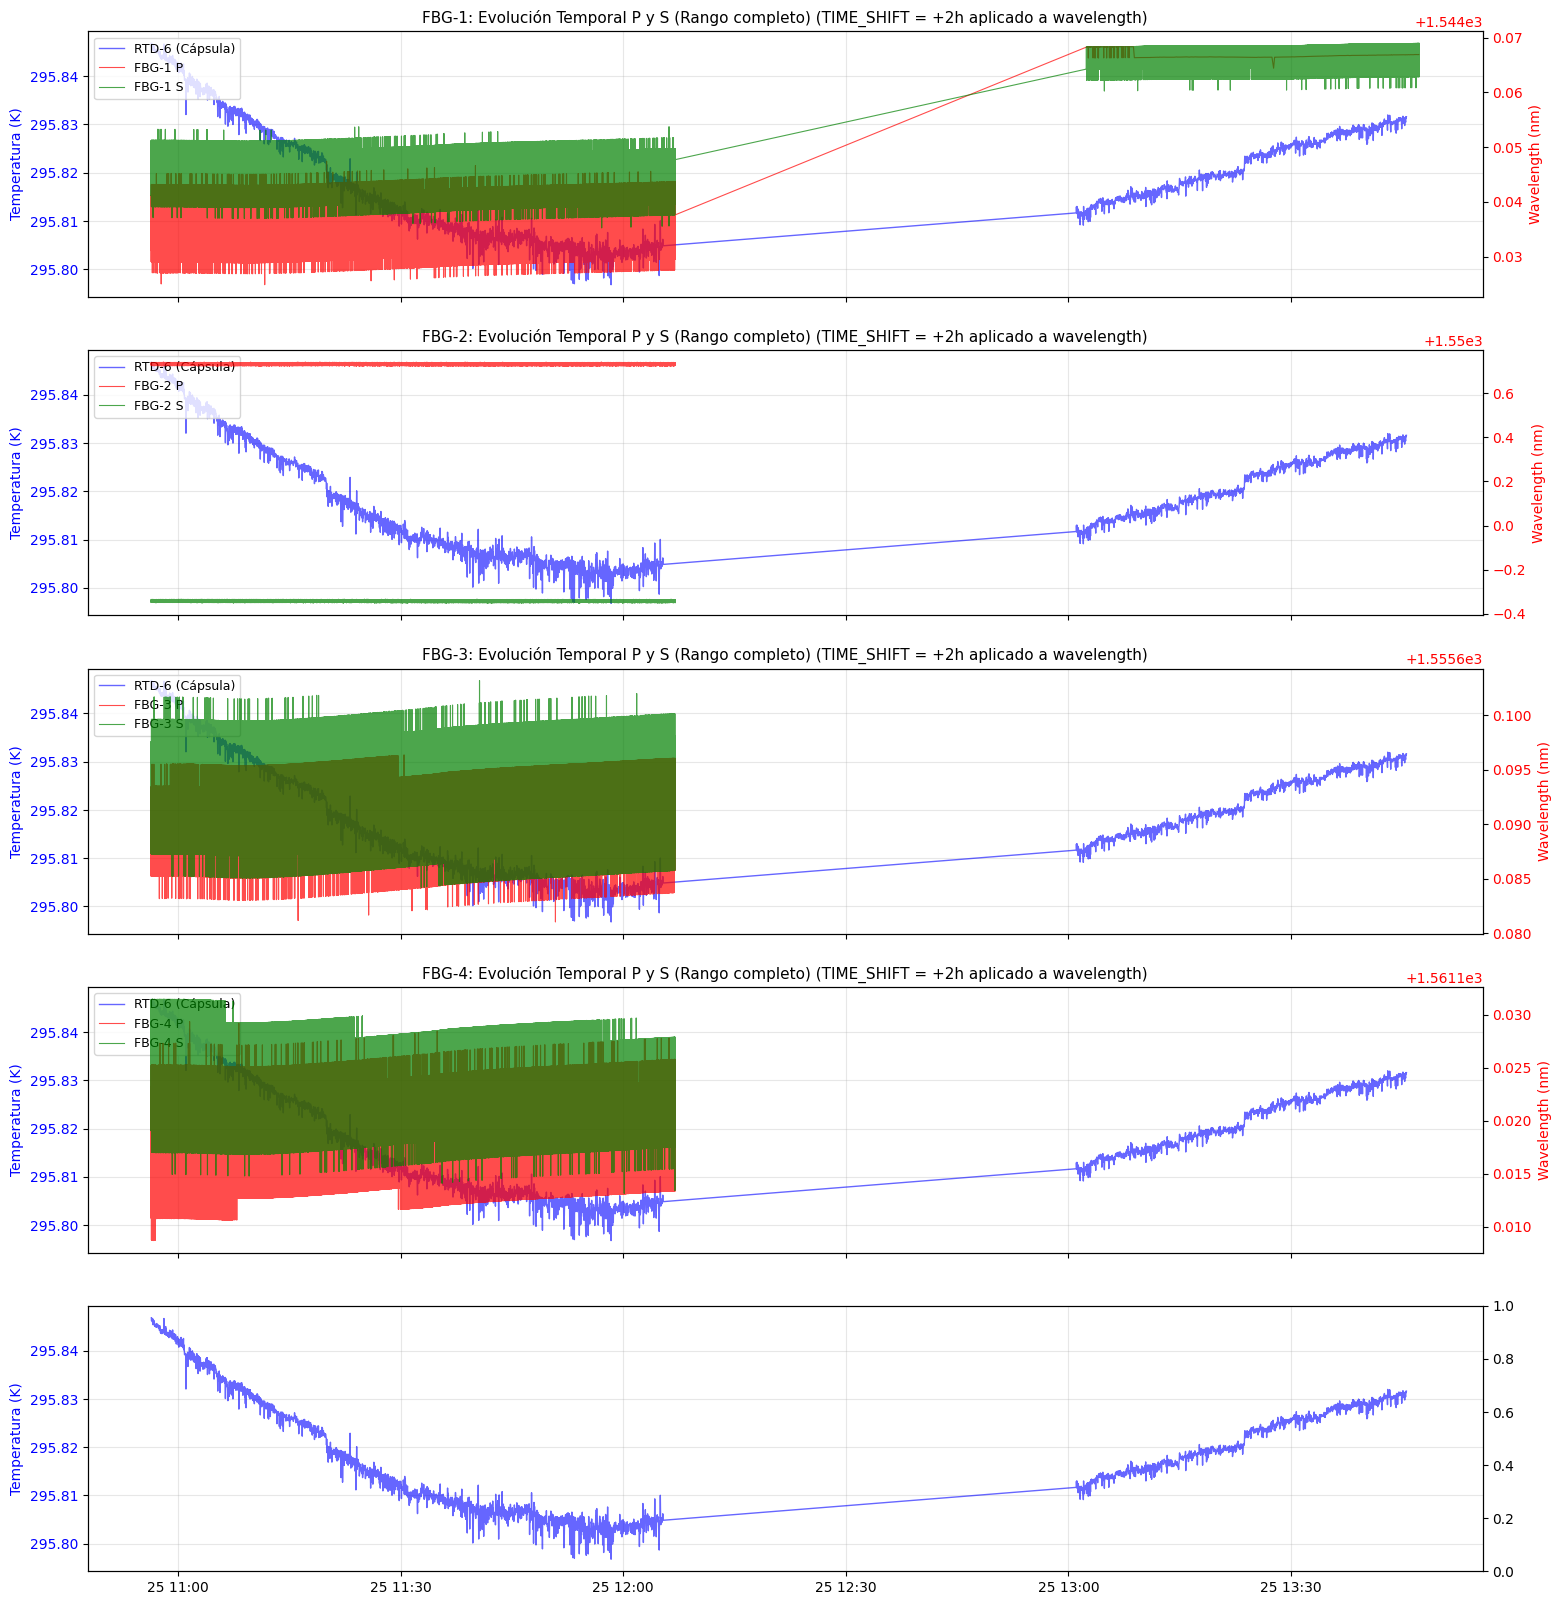

In [ ]:
# ============================================================================
# EVOLUCIÓN TEMPORAL DE POLARIZACIONES P Y S POR SEPARADO
# ============================================================================
# Mostramos la evolución temporal de cada polarización (P y S) por separado para cada sensor

fig, axes = plt.subplots(n_sensors_temporal, 1, figsize=(18, 4*n_sensors_temporal), sharex=True)
if n_sensors_temporal == 1:
    axes = [axes]

for idx, sensor_num in enumerate(range(1, num_sensores + 1)):
    if idx >= len(axes):
        break
    fbg_label = f"FBG-{sensor_num}-Mean"
    if fbg_label not in fbg_mean_data:
        continue

    sensor_idx = sensor_num - 1  # 0-indexed
    wav_p_full = wav_raw[:, 0, sensor_idx]  # Polarización P
    wav_s_full = wav_raw[:, 1, sensor_idx]  # Polarización S

    # Filtro robusto de outliers y rango temporal
    def robust_mask(arr):
        valid = arr > 0
        if np.sum(valid) == 0:
            return valid
        med = np.median(arr[valid])
        mad = np.median(np.abs(arr[valid] - med))
        if mad == 0:
            mad = np.std(arr[valid]) * 0.6745  # fallback
        return valid & (np.abs(arr - med) <= 5 * mad)

    mask_p = robust_mask(wav_p_full) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)
    mask_s = robust_mask(wav_s_full) & (times_peak >= t_plot_inicio) & (times_peak <= t_plot_fin)

    times_p_plot = times_peak[mask_p]
    times_s_plot = times_peak[mask_s]
    wav_p_plot_valid = wav_p_full[mask_p] * 1e9  # Convertir a nm
    wav_s_plot_valid = wav_s_full[mask_s] * 1e9  # Convertir a nm

    ax = axes[idx]

    # Plot temperatura
    ax.plot(times_temp_plot, temp_plot, 'b-', linewidth=1.0, alpha=0.6, label=f'{rtd_ref_name}')
    ax.set_ylabel('Temperatura (K)', fontsize=10, color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.grid(True, alpha=0.3)

    # Plot wavelength P y S en eje secundario
    ax2 = ax.twinx()
    ax2.plot(times_p_plot, wav_p_plot_valid, 'r-', linewidth=0.8, alpha=0.7, label=f'FBG-{sensor_num} P')
    ax2.plot(times_s_plot, wav_s_plot_valid, 'g-', linewidth=0.8, alpha=0.7, label=f'FBG-{sensor_num} S')
    ax2.set_ylabel('Wavelength (nm)', fontsize=10, color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    # Leyenda combinada
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

    ax.set_title(f'FBG-{sensor_num}: Evolución Temporal P y S {range_label} (TIME_SHIFT = +{TIME_SHIFT.total_seconds()/3600:.0f}h aplicado a wavelength)',
                 fontsize=11)

axes[-1].set_xlabel('Tiempo', fontsize=11)
for label in axes[-1].get_xticklabels():
    label.set_rotation(45)
    label.set_ha('right')

plt.suptitle(f'Evolución Temporal: {rtd_ref_name} vs FBG Sensors (P y S por separado)',
             fontsize=13, y=0.995)
plt.tight_layout()
plt.show()

print(f"\n📊 Rango temporal mostrado: {range_label}")
if len(times_temp_plot) > 0:
    print(f"   Temperatura: {times_temp_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_temp_plot[-1].strftime('%H:%M')}")
if len(times_p_plot) > 0:
    print(f"   Wavelength P: {times_p_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_p_plot[-1].strftime('%H:%M')}")
if len(times_s_plot) > 0:
    print(f"   Wavelength S: {times_s_plot[0].strftime('%Y-%m-%d %H:%M')} - {times_s_plot[-1].strftime('%H:%M')}")
print(f"\n💡 TIME_SHIFT de {TIME_SHIFT.total_seconds()/3600:.0f}h aplicado a wavelength para alinear con temperatura.")
if use_filtered_range_plot:
    print(f"\n⚙️  Para ver el rango completo: cambia 'use_filtered_range_plot = False'")
else:
    print(f"\n⚙️  Para filtrar por rango temporal específico: cambia 'use_filtered_range_plot = True'")